In [100]:
import torch
from torch import nn
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.nn.utils.prune as prune

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchmetrics import Accuracy

import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
import copy
import gc
import math

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from resnet_18 import *

import cv2
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from math import ceil

from craft.craft_torch import Craft, torch_to_numpy

import matplotlib
import colorsys

In [101]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [102]:
model_architecture = 'resnet18' 
checkpoint_path = 'saves/resnet/imagenette/29_model_lt.pth.tar'

# model = timm.create_model(model_architecture,pretrained=False,num_classes=10 )
model= resnet_18()
loaded_object = torch.load(checkpoint_path, map_location=device, weights_only=False)
state_dict = loaded_object.state_dict()
model.load_state_dict(state_dict)
model = model.eval().to(device)

In [103]:
# processing
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
to_pil = transforms.ToPILImage()

# cut the model in two
g = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4
)
h = nn.Sequential(
    model.global_pool,
    nn.Flatten(1), # Flattens the output of the pool layer for the fc layer
    model.fc
) 

In [104]:
springer_class = 9 # imagenette class for springer

# loading some images of rabbits !
images = np.load('collected_images/parachute.npz')['images']
images_preprocessed = torch.from_numpy(images)

images_preprocessed.shape

torch.Size([500, 3, 224, 224])

In [105]:
craft = Craft(input_to_latent = g,
              latent_to_logit = h,
              number_of_concepts = 10,
              patch_size = 64,
              batch_size = 64,
              device = device)

crops, crops_u, w = craft.fit(images_preprocessed)
crops = np.moveaxis(torch_to_numpy(crops), 1, -1)

crops.shape, crops_u.shape, w.shape

((8000, 64, 64, 3), (8000, 10), (10, 512))

In [106]:
importances = craft.estimate_importance(images_preprocessed, class_id=springer_class)
images_u = craft.transform(images_preprocessed)

images_u.shape

(500, 7, 7, 10)

Concept 7  has an importance value of  0.3627494
Concept 0  has an importance value of  0.05376623
Concept 8  has an importance value of  0.05271867
Concept 4  has an importance value of  0.040056355
Concept 2  has an importance value of  0.025662053


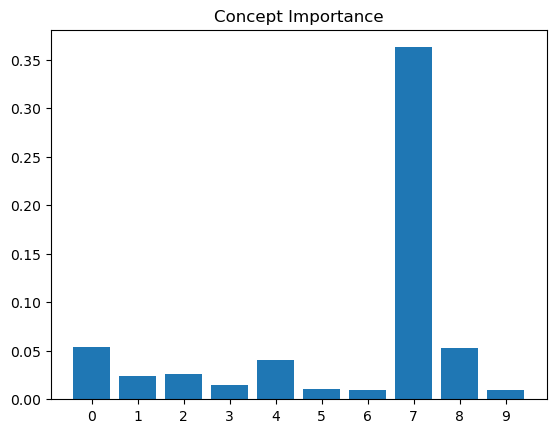

In [107]:
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

most_important_concepts = np.argsort(importances)[::-1][:5]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

Concept 7  has an importance value of  0.3627494


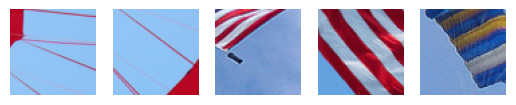




Concept 0  has an importance value of  0.05376623


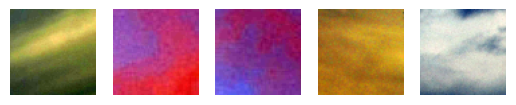




Concept 8  has an importance value of  0.05271867


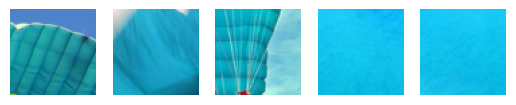




Concept 4  has an importance value of  0.040056355


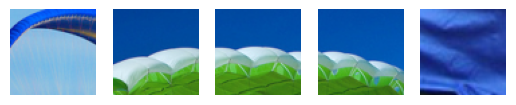




Concept 2  has an importance value of  0.025662053


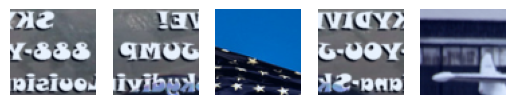

In [108]:
import os
nb_crops = 5
output_dir = 'concept_visualizations/prune_70/parachute'
os.makedirs(output_dir, exist_ok=True)

def show(img, **kwargs):
    img = np.array(img)
    if img.shape[0] == 3:
        img = img.transpose(1, 2, 0)
    
    img -= img.min();img /= img.max()
    plt.imshow(img, **kwargs); plt.axis('off')

for c_id in most_important_concepts:
    best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
    best_crops = crops[best_crops_ids]
    
    print("Concept", c_id, " has an importance value of ", importances[c_id])
    for i in range(nb_crops):
        plt.subplot(ceil(nb_crops/5), 5, i+1)
        show(best_crops[i])
        
    save_path = os.path.join(output_dir, f'concept_{c_id}.png')
    # Save the figure to the specified file path
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('\n\n')